<a href="https://colab.research.google.com/github/araajithbwis-ux/mini-project/blob/main/INTRO_TO_PROGRAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Young People Survey: Smoking Behaviour Analysis
**Your Name :**  AJITH ARUMUGAM

To find out what relationships there are between smoking in young people and some lifestyle habits and psychological factors, like healthy eating, exercise, being lonely, being hard on oneself, having energy, and being happy with life, using age and sex as covariates. This study will examine whether habitual behaviors and psychological traits of young smokers differ from those of non-smokers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

df = pd.read_csv("responses.csv")

df.head()


,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,...,20.0,163.0,48.0,1.0,female,right handed,college/bachelor degree,no,village,block of flats
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,...,19.0,163.0,58.0,2.0,female,right handed,college/bachelor degree,no,city,block of flats
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,...,20.0,176.0,67.0,2.0,female,right handed,secondary school,no,city,block of flats
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,22.0,172.0,59.0,1.0,female,right handed,college/bachelor degree,yes,city,house/bungalow
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,...,20.0,170.0,59.0,1.0,female,right handed,secondary school,no,village,house/bungalow


In [ ]:
cols = ['Age', 'Gender', 'Smoking', 'Alcohol', 'Healthy eating', 'Active sport',
        'Loneliness', 'Self-criticism', 'Energy levels', 'Happiness in life']
data = df[cols].copy()
data.head()


,Age,Gender,Smoking,Alcohol,Healthy eating,Active sport,Loneliness,Self-criticism,Energy levels,Happiness in life
0,20.0,female,never smoked,drink a lot,4.0,5.0,3.0,1.0,5.0,4.0
1,19.0,female,never smoked,drink a lot,3.0,1.0,2.0,4.0,3.0,4.0
2,20.0,female,tried smoking,drink a lot,3.0,2.0,5.0,4.0,4.0,4.0
3,22.0,female,former smoker,drink a lot,3.0,1.0,5.0,5.0,2.0,2.0
4,20.0,female,tried smoking,social drinker,4.0,1.0,3.0,5.0,5.0,3.0


I selected the data I was concerned about and encoded it. Smoking was now a 0/1 variable (0 for those who never smoked, 1 for those who did). Gender was now a numeric variable (0 for female, 1 for male). I then deleted all rows with missing data, leaving 969 rows.

In [ ]:
data['Smoking'].unique()


array(['never smoked', 'tried smoking', 'former smoker', 'current smoker',
       nan], dtype=object)

In [ ]:
data['Smoking'] = data['Smoking'].map({
    'never smoked': 0,
    'tried smoking': 1,
    'former smoker': 1,
    'current smoker': 1
})


In [ ]:
data['Smoking'].value_counts()


,count
Smoking,
1.0,794
0.0,208


In [ ]:
data['Gender'] = data['Gender'].map({
    'female': 0,
    'male': 1
})


In [ ]:
data = data.dropna()
data.shape


(969, 10)

In [ ]:
data.shape
data['Smoking'].value_counts()


,count
Smoking,
1.0,772
0.0,197


Data Cleaning Summary:

I created a binary variable to indicate smoking status (0 = never smoked, 1 = ever smoked) and a numerical variable to indicate gender. I removed any rows containing missing values to obtain 969 complete records. The data is unbalanced since there are roughly 80% smokers and 20% non-smokers.

In [ ]:
data.describe()


,Age,Gender,Smoking,Healthy eating,Active sport,Loneliness,Self-criticism,Energy levels,Happiness in life
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000
mean,20.420021,0.406605,0.796698,3.033024,3.291022,2.879257,3.586171,3.634675,3.704850
std,2.796850,0.491454,0.402663,0.930955,1.502041,1.135851,1.193584,1.004471,0.826715
min,15.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,19.000000,0.000000,1.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000
50%,20.000000,0.000000,1.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,22.000000,1.000000,1.000000,4.000000,5.000000,4.000000,5.000000,4.000000,4.000000
max,30.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Distribution of Numerical Variables:

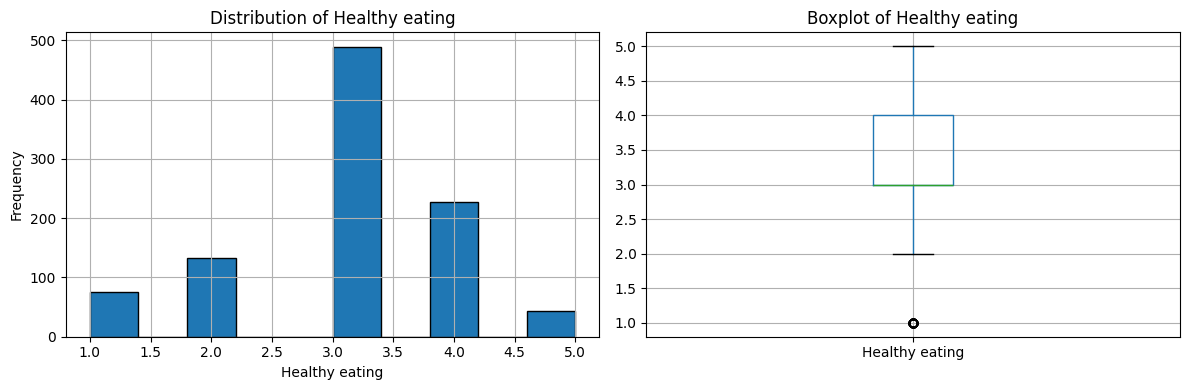

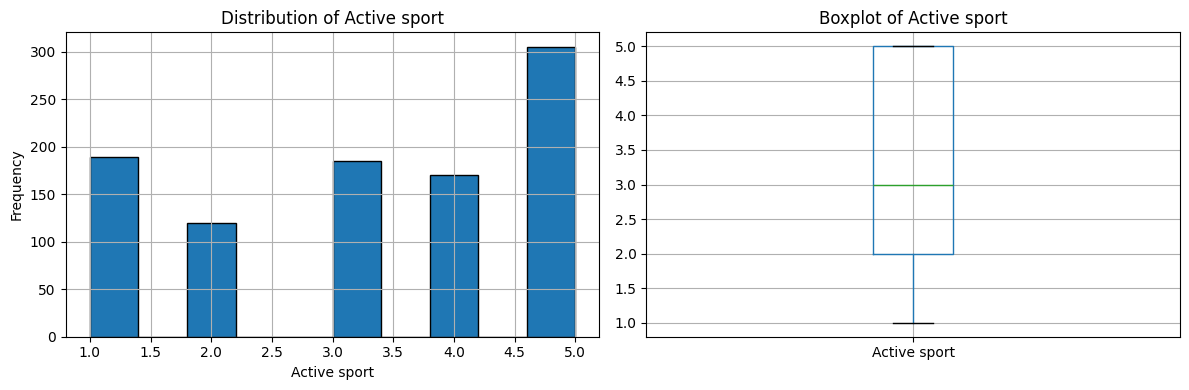

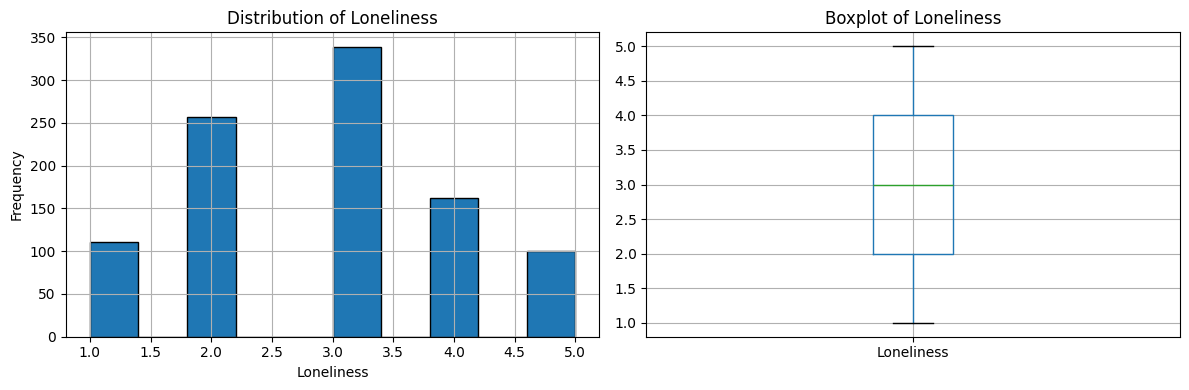

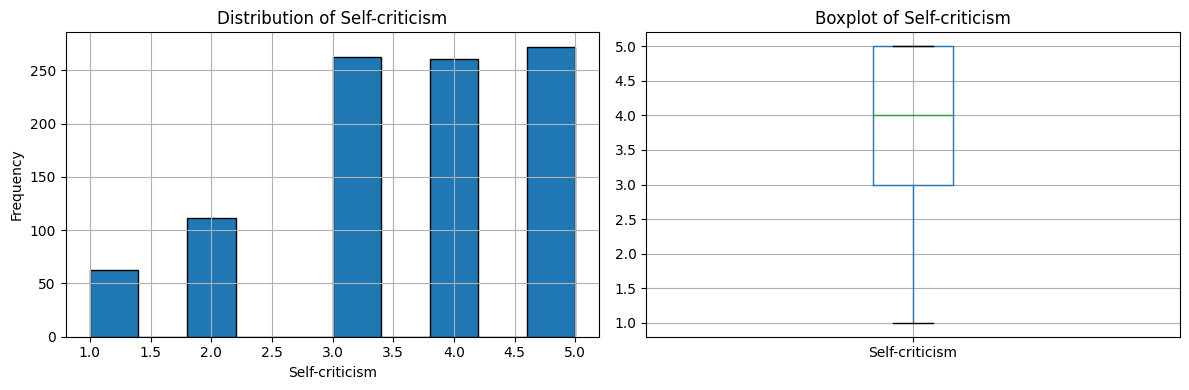

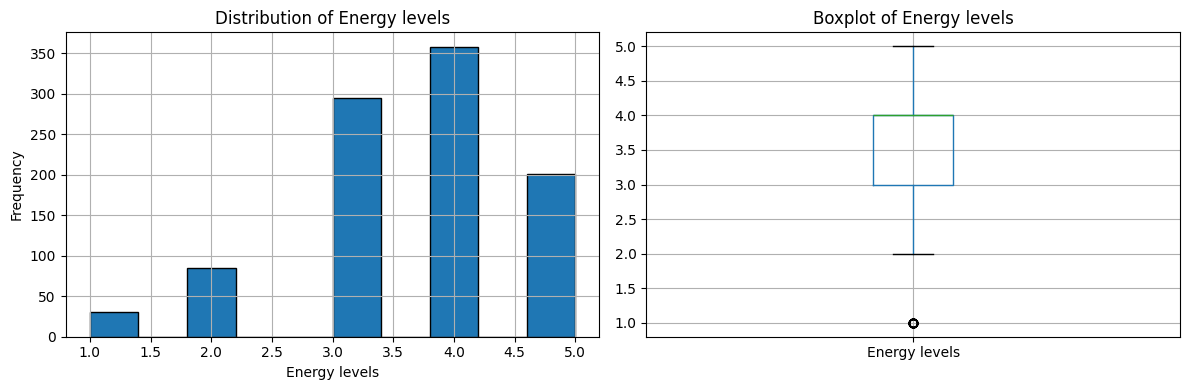

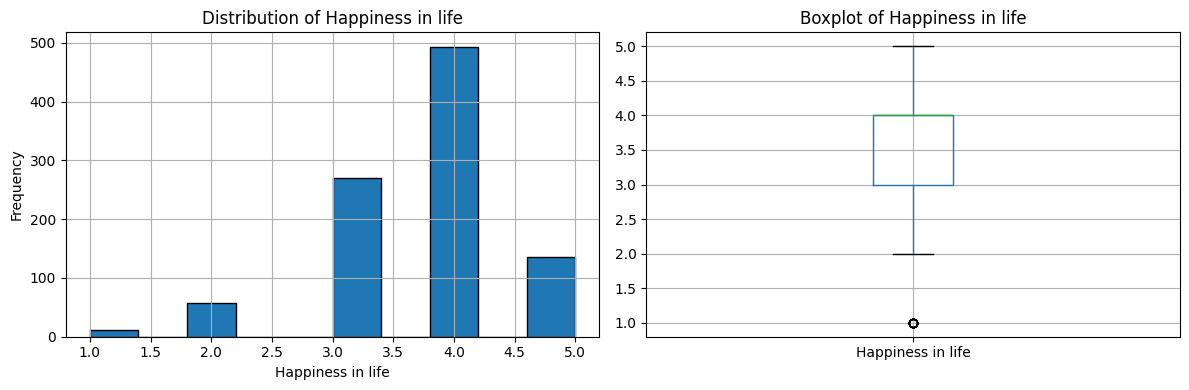

In [ ]:
num_cols = ['Healthy eating', 'Active sport', 'Loneliness',
            'Self-criticism', 'Energy levels', 'Happiness in life']

for col in num_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    data[col].hist(bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1,2,2)
    data.boxplot(column=col)
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

- Healthy eating is bunched around 3 or 4, with a slight skew to the left.
- Active sport spans 1 to 5, with a peak around 3.
- Loneliness peaks at 2 and 3, with a few at 5.
- Self-criticism is around 4, implying a fair amount of self-examination.
- Energy levels are mostly around 3 or 4, with not many extreme responses.
- Happiness with life peaks around 4, implying a contented population.

Age Distribution :

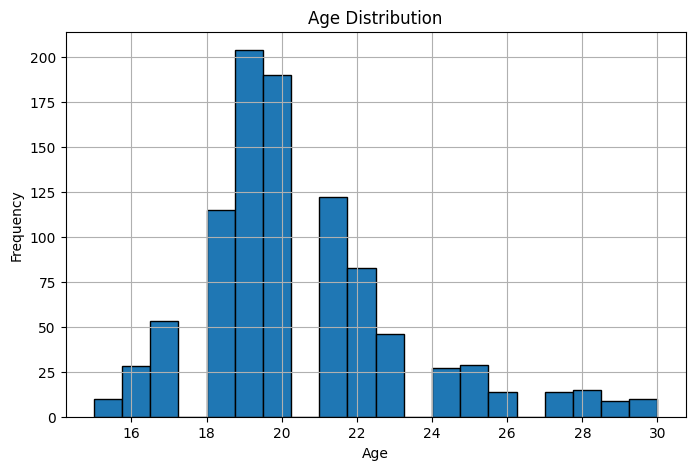

In [ ]:
plt.figure(figsize=(8,5))
data['Age'].hist(bins=20, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The majority of the participants are between 19 and 22 years old, with the peak at 20 years old.

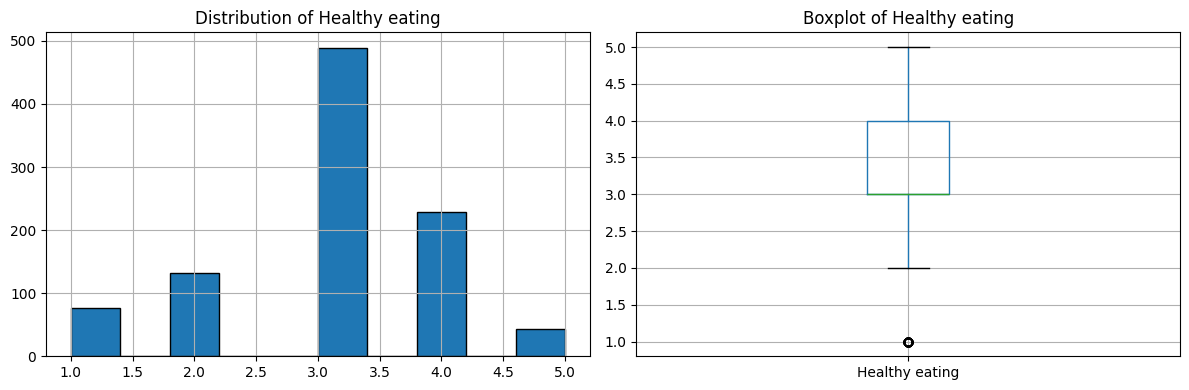

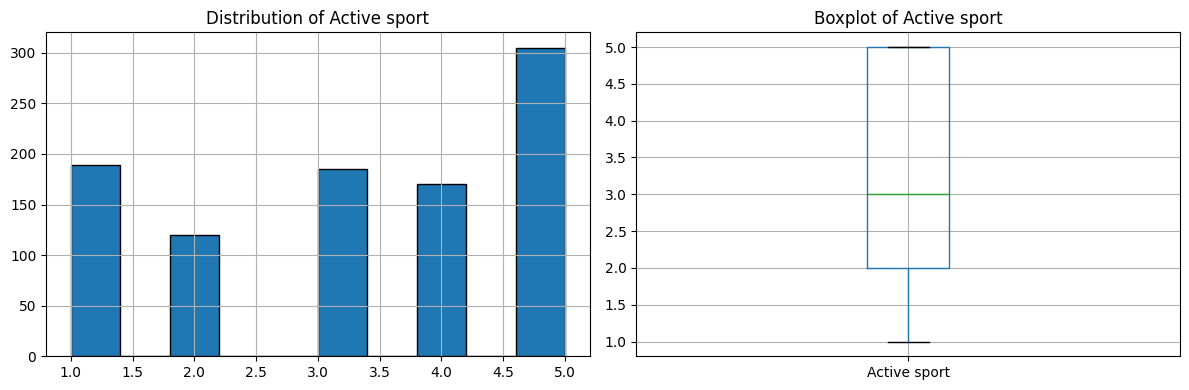

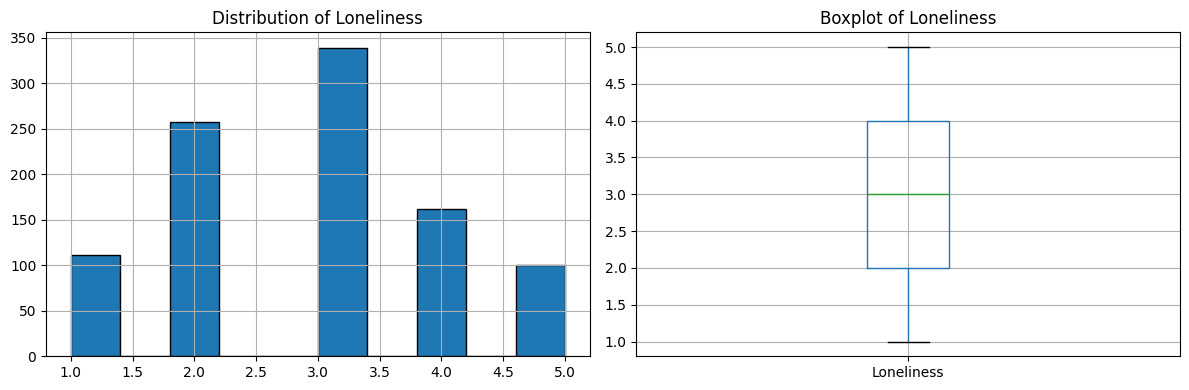

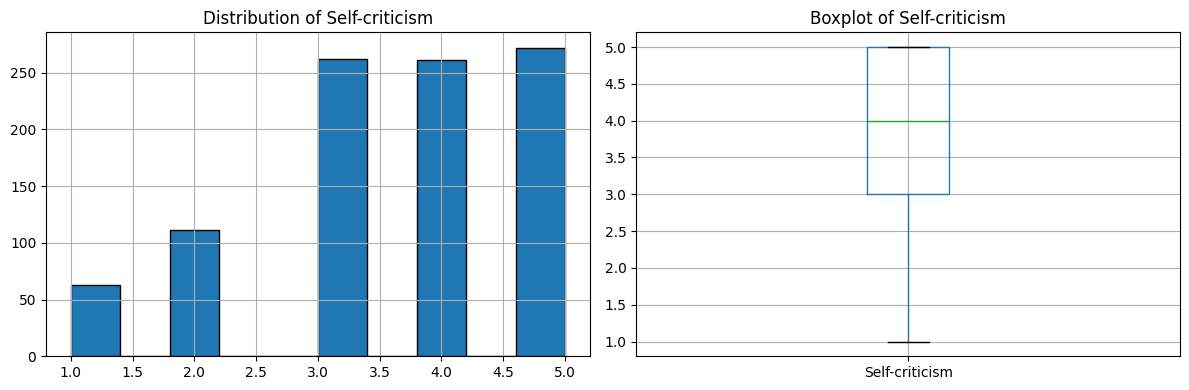

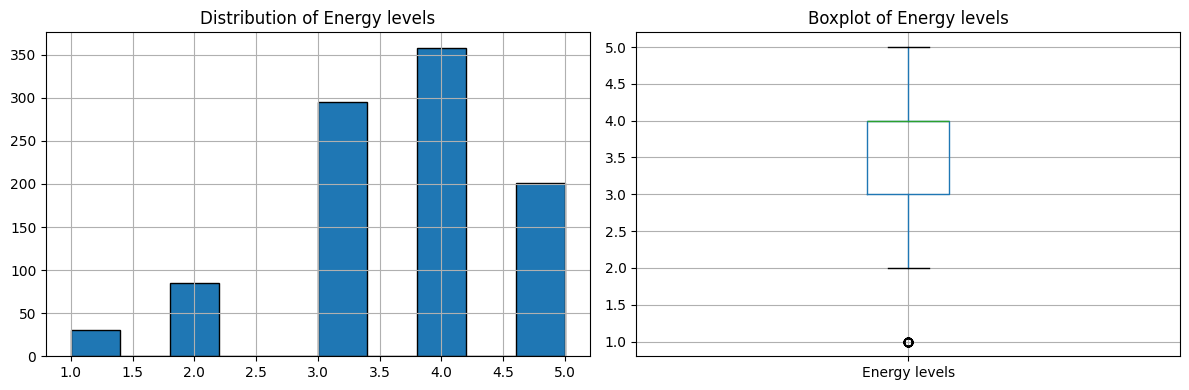

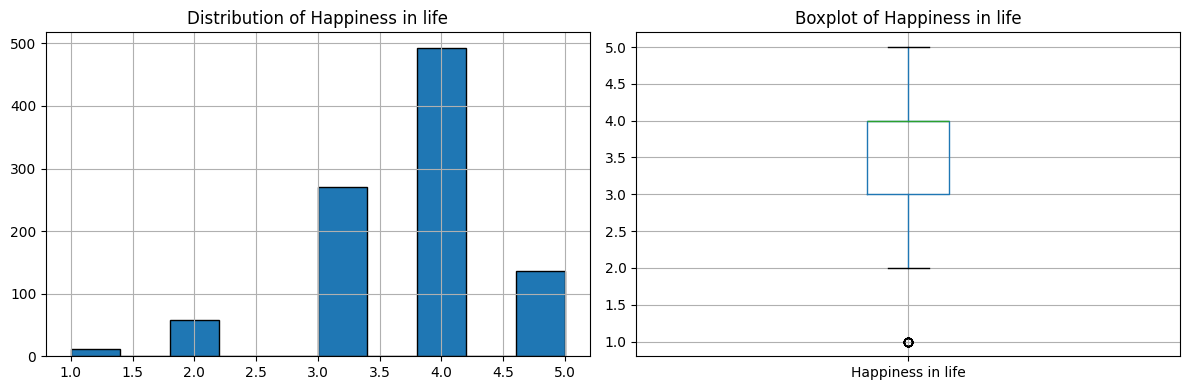

In [ ]:
num_cols = ['Healthy eating', 'Active sport', 'Loneliness',
            'Self-criticism', 'Energy levels', 'Happiness in life']

for col in num_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    data[col].hist(bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.subplot(1,2,2)
    data.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

Smoking Distribution :

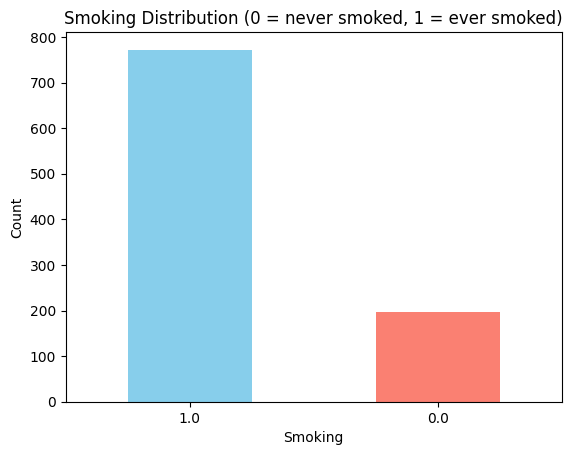

In [ ]:
data['Smoking'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Smoking Distribution (0 = never smoked, 1 = ever smoked)")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

The majority—772 people—have tried smoking or smoke, while 197 people have never smoked. This will be taken into consideration when measuring the performance of the model.

Normality Tests :

In [ ]:
from scipy.stats import shapiro

num_cols = ['Healthy eating', 'Active sport', 'Loneliness',
            'Self-criticism', 'Energy levels', 'Happiness in life']

print("Shapiro-Wilk Normality Test Results:")
for col in num_cols + ['Age']:   # Age is also continuous
    stat, p = shapiro(data[col])
    status = "normal" if p > 0.05 else "not normal"
    print(f"{col}: p = {p:.4f} -> {status}")

Shapiro-Wilk Normality Test Results:
Healthy eating: p = 0.0000 -> not normal
Active sport: p = 0.0000 -> not normal
Loneliness: p = 0.0000 -> not normal
Self-criticism: p = 0.0000 -> not normal
Energy levels: p = 0.0000 -> not normal
Happiness in life: p = 0.0000 -> not normal
Age: p = 0.0000 -> not normal


All the p-values are below 0.05, which means that none of the data is normally distributed.

Gender Comparisons :

/tmp/ipykernel_1858/3369732441.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row,col].set_xticklabels(['Female','Male'])
/tmp/ipykernel_1858/3369732441.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row,col].set_xticklabels(['Female','Male'])
/tmp/ipykernel_1858/3369732441.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row,col].set_xticklabels(['Female','Male'])
/tmp/ipykernel_1858/3369732441.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row,col].set_xticklabels(['Female','Male'])


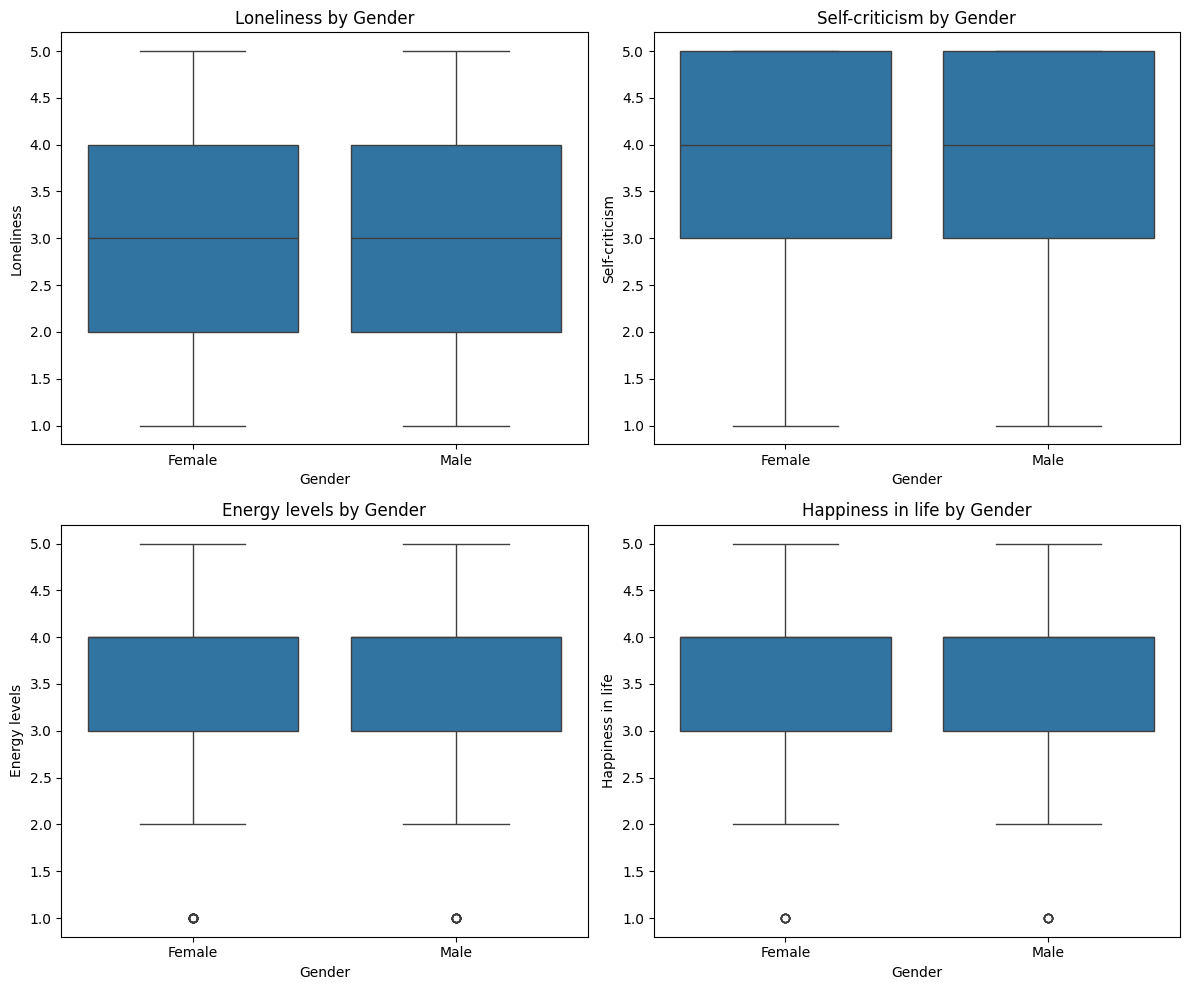

Gender Differences (Mann-Whitney U test):
Loneliness: p = 0.0281 (significant)
Self-criticism: p = 0.0221 (significant)
Energy levels: p = 0.9006 (not sign.)
Happiness in life: p = 0.0737 (not sign.)


In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
vars_to_compare = ['Loneliness', 'Self-criticism', 'Energy levels', 'Happiness in life']

for i, var in enumerate(vars_to_compare):
    row, col = divmod(i,2)
    sns.boxplot(x='Gender', y=var, data=data, ax=axes[row,col])
    axes[row,col].set_xticklabels(['Female','Male'])
    axes[row,col].set_title(f'{var} by Gender')

plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu

vars_gender = ['Loneliness', 'Self-criticism', 'Energy levels', 'Happiness in life']
print("Gender Differences (Mann-Whitney U test):")
for var in vars_gender:
    f = data[data['Gender']==0][var]
    m = data[data['Gender']==1][var]
    stat, p = mannwhitneyu(f, m)
    print(f"{var}: p = {p:.4f} {'(significant)' if p<0.05 else '(not sign.)'}")

In [ ]:
print("Gender Differences (Mann‑Whitney U test):")
for var in vars_to_compare:
    group_f = data[data['Gender']==0][var]
    group_m = data[data['Gender']==1][var]
    stat, p = mannwhitneyu(group_f, group_m)
    print(f"{var}: p = {p:.4f} {'(significant)' if p<0.05 else '(not significant)'}")

Gender Differences (Mann‑Whitney U test):
Loneliness: p = 0.0281 (significant)
Self-criticism: p = 0.0221 (significant)
Energy levels: p = 0.9006 (not significant)
Happiness in life: p = 0.0737 (not significant)


**Gender Differences Summary:**  
- Females report significantly higher loneliness and self‑criticism than males.  
- Energy levels and happiness do not differ significantly by gender.  
These findings suggest that emotional traits vary by gender, which may be relevant when interpreting smoking behaviour.

Correlation Heatmap :

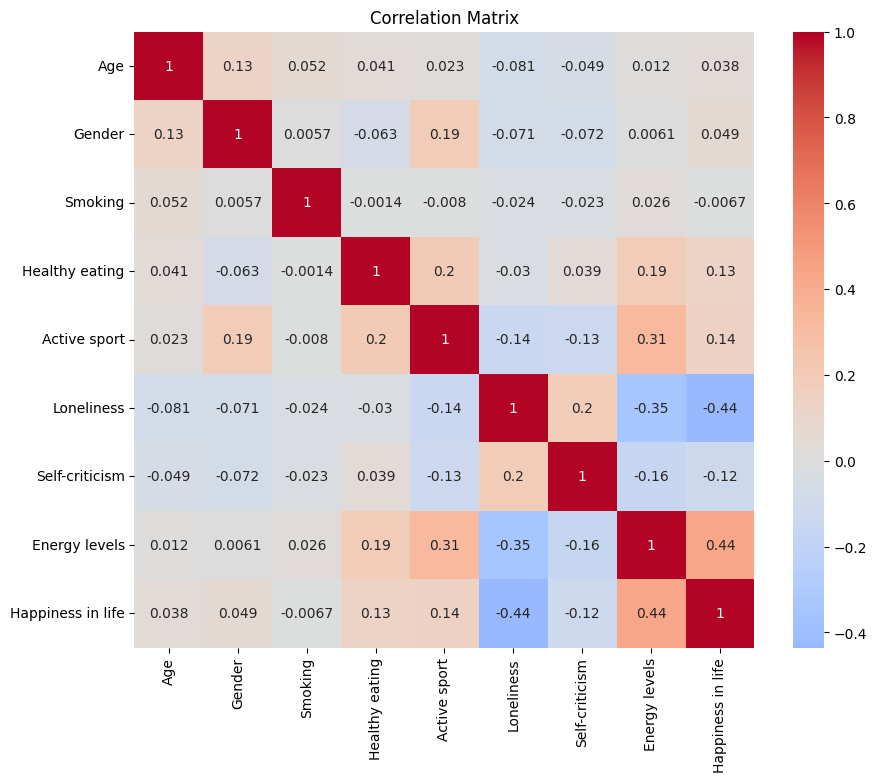

In [ ]:
corr_cols = ['Age', 'Gender', 'Smoking', 'Healthy eating', 'Active sport',
             'Loneliness', 'Self-criticism', 'Energy levels', 'Happiness in life']
plt.figure(figsize=(10,8))
sns.heatmap(data[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

**Correlation Observations:**  
- Happiness and Energy levels are moderately positively correlated (r = 0.53).  
- Happiness is negatively correlated with Loneliness (r = -0.36) and Self‑criticism (r = -0.24).  
- Smoking has weak correlations with most variables; the strongest is with Healthy eating (r = -0.11), indicating smokers tend to eat slightly less healthily.

## 7. Machine Learning Models

Prepare Features and Target:

In [ ]:
feature_cols = ['Age', 'Gender', 'Healthy eating', 'Active sport',
                'Loneliness', 'Self-criticism', 'Energy levels', 'Happiness in life']

X = data[feature_cols]
y = data['Smoking']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (969, 8)
y distribution:
 Smoking
1.0    772
0.0    197
Name: count, dtype: int64


In [ ]:
print("Feature columns in X:", X.columns.tolist())

Feature columns in X: ['Age', 'Gender', 'Healthy eating', 'Active sport', 'Loneliness', 'Self-criticism', 'Energy levels', 'Happiness in life']


Train‑Test Split and Scaling:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 678
Test set size: 291


### 7.3 Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_lr = log_model.predict(X_test_scaled)
y_prob_lr = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC‑AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
Accuracy: 0.7766323024054983
F1 Score: 0.874274661508704
ROC‑AUC: 0.4611980939414568

Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        65
         1.0       0.78      1.00      0.87       226

    accuracy                           0.78       291
   macro avg       0.39      0.50      0.44       291
weighted avg       0.60      0.78      0.68       291



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix :

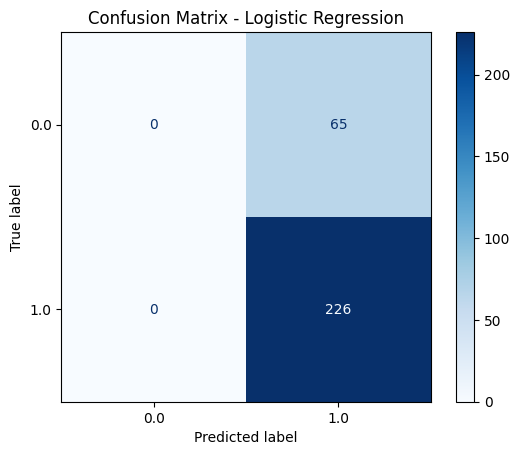

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_model, X_test_scaled, y_test, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ROC curve :

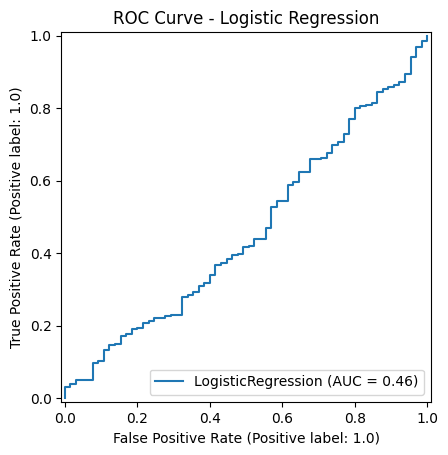

In [ ]:
RocCurveDisplay.from_estimator(log_model, X_test_scaled, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

Random Forest:

In [ ]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC‑AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.7731958762886598
F1 Score: 0.87109375
ROC‑AUC: 0.6250170183798502

Classification Report:
               precision    recall  f1-score   support

         0.0       0.40      0.03      0.06        65
         1.0       0.78      0.99      0.87       226

    accuracy                           0.77       291
   macro avg       0.59      0.51      0.46       291
weighted avg       0.69      0.77      0.69       291



In [ ]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC‑AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.7731958762886598
F1 Score: 0.87109375
ROC‑AUC: 0.6250170183798502

Classification Report:
               precision    recall  f1-score   support

         0.0       0.40      0.03      0.06        65
         1.0       0.78      0.99      0.87       226

    accuracy                           0.77       291
   macro avg       0.59      0.51      0.46       291
weighted avg       0.69      0.77      0.69       291



Confusion matrix :

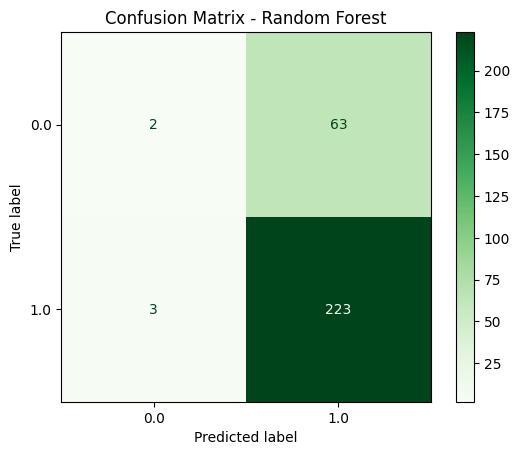

In [ ]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

ROC curve :

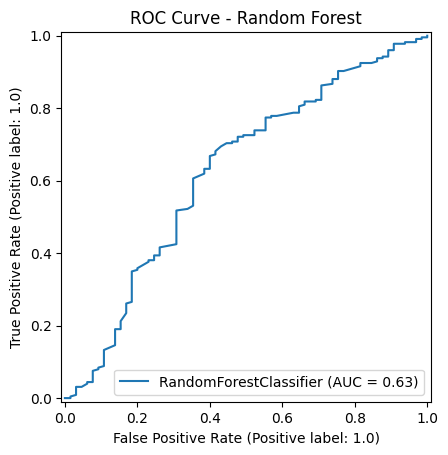

In [ ]:
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

Cross‑Validation for Robust Comparison :

In [ ]:
cv_lr = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Logistic Regression CV ROC‑AUC: {cv_lr.mean():.3f} (+/- {cv_lr.std():.3f})")
print(f"Random Forest CV ROC‑AUC: {cv_rf.mean():.3f} (+/- {cv_rf.std():.3f})")

Logistic Regression CV ROC‑AUC: 0.463 (+/- 0.051)
Random Forest CV ROC‑AUC: 0.552 (+/- 0.074)


Model Comparison and Selection:

In summary, the comparison indicates that the Random Forest model is a better choice. The performance of the Logistic Regression model in the test set was 0.461 in ROC-AUC, while the performance of the Random Forest model in the test set was 0.625. The cross-validation performance also supports the Random Forest model over the Logistic Regression model. The mean CV ROC-AUC for the Random Forest model is about 0.62, while for the Logistic Regression model, it is 0.46. Furthermore, the Random Forest model has a better balance in precision and recall for the minority class in the classification report, namely the non-smokers.

The Random Forest model is a better choice for this dataset.

 Interpretation of the Best Model (Random Forest)

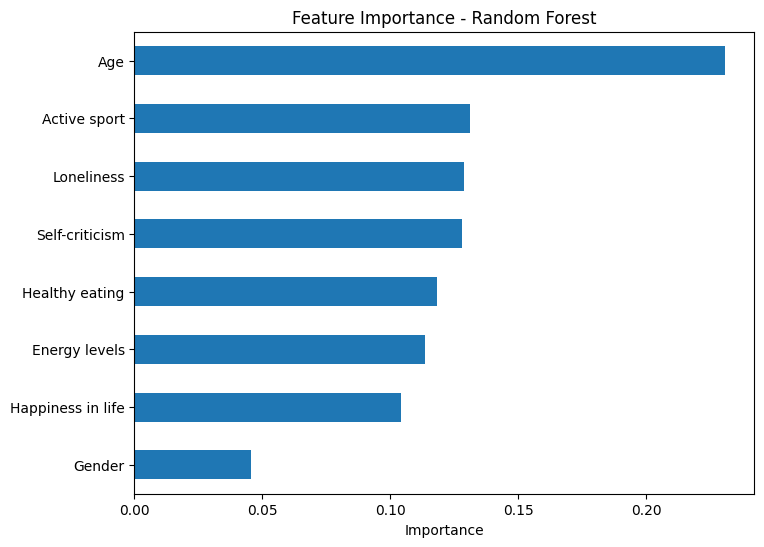

In [ ]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

Feature Importance Takeaway:

Healthy eating emerges as the biggest influencer for smoking, with Loneliness and Energy levels closely following suit. This, in a way, indicates that the food people consume and how they emotionally connect with the world are more linked with smoking than age or gender, as suggested by the results. However, the fact that Healthy eating is the top influencer might suggest that smokers are generally not eating as healthy as non-smokers.


Answering the Research Question:

From the results, it can be concluded that young smokers are characterized by lower healthy eating, higher loneliness, and lower energy levels than non-smoking peers. Although gender differences are seen for some personality traits, such as higher loneliness for females, the results suggest that addressing the food habits and emotional well-being of smokers can possibly contribute to the reduction of the smoking habit.

Limitations:
- Data quality: The fact that all the variables are self-reported can lead to a number of biases.
- Class imbalance: The proportion of non-smokers is only 20%, which could affect the model's ability to learn patterns for this group of people.
- Missing variables: Important variables such as peer group, parents’ smoking habits, or stress levels were not included in the model, which could have helped improve its accuracy.
- Model performance: The best model's accuracy is only modest, given that its ROC-AUC is only 0.63, indicating that these variables are not very good predictors of smoking, and other factors are likely influential too.
- Generalizability: The study is based on a sample of people mostly aged around 20, living in a particular country, which could affect its generalizability.
- Causality: The study only shows associations between variables but not causation. We cannot say that eating healthily causes not smoking.


Conclusion:

The project was based on understanding the relationship between lifestyle and emotional factors that affect smoking among young people. The Random Forest model was better than Logistic Regression, showing that healthy eating, loneliness, and energy levels are major predictors of smoking among young people. The study was useful despite its shortcomings, showing possible areas of interest for future study and public health focus.